In [2]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
font_dirs = ["/content/drive/MyDrive/NU work/Font"]  # The path to the custom font file./content/Arial.ttf
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

print(font_files)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
font_manager.get_font_names()

matplotlib.rcParams['font.family'] = "Arial"
matplotlib.rcParams['font.sans-serif'] = ["Arial"]


plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 8

['/content/drive/MyDrive/NU work/Font/Arial Italic.ttf', '/content/drive/MyDrive/NU work/Font/Arial Bold Italic.ttf', '/content/drive/MyDrive/NU work/Font/Arial.ttf', '/content/drive/MyDrive/NU work/Font/Arial Bold.ttf']


In [3]:
import pandas as pd
data_water = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/Python outputs/water consumption.xlsx',index_col=0)
data_abandonment = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/Python outputs/abandonment_rate.xlsx',index_col=0).iloc[:, ::-1]


print(data_water)
print(data_abandonment)


weather_historical = pd.read_csv('/content/drive/MyDrive/NU work/Cotton/Weather/CMIP/historical/results_his_8f.csv')
weather_ssp1 =pd.read_csv('/content/drive/MyDrive/NU work/Cotton/Weather/CMIP/SSP1/results_SSP1_8f.csv')
weather_ssp2 =pd.read_csv('/content/drive/MyDrive/NU work/Cotton/Weather/CMIP/SSP2/results_SSP2_8f.csv')
weather_ssp3 =pd.read_csv('/content/drive/MyDrive/NU work/Cotton/Weather/CMIP/SSP3/results_SSP3_8f.csv')
weather_ssp5 =pd.read_csv('/content/drive/MyDrive/NU work/Cotton/Weather/CMIP/SSP5/results_SSP5_8f.csv')


                       2000         2001         2002         2003  \
Category                                                             
ALABAMA          102.765255    70.220929   120.648726    73.951719   
ARIZONA         7500.646010  9029.015663  7442.296170  8238.438975   
ARKANSAS        1994.546736  1827.335826  1867.512451  1777.362909   
CALIFORNIA      4872.221507  4889.151217  4527.283904  5079.884101   
FLORIDA          299.248108   188.877006   292.126139   199.150281   
GEORGIA          492.027251   385.141128   554.948116   384.334182   
KANSAS          3005.335092  2244.266430  1748.845060  1565.798717   
LOUISIANA        623.948933   710.362159   629.607148   445.096714   
MISSISSIPPI      950.806385   861.166881   782.966565   703.119615   
MISSOURI        1569.275151  1324.477326  1511.868130  1389.478814   
NEW MEXICO      5726.549167  4319.074919  4829.580820  5637.234423   
NORTH CAROLINA    34.976196    33.009695    69.738069    45.532322   
OKLAHOMA        3875

In [4]:
import numpy as np
import matplotlib.pyplot as plt
# print(data_water, weather_historical.shape)

def process_weather_data(weather_historical, total_month, start=0, end=None):
  weather_historical = np.array(weather_historical).reshape(8, 17, total_month).reshape(8, 17, 12, total_month//12).transpose(1, 0, 2, 3).reshape(17, 96, total_month//12)[:,:,start:end]
  new_indices = [9, 15, 16, 8, 5, 10, 13, 4, 0, 11, 6, 1, 2, 14, 12, 7, 3]
  weather_historical_reordered = weather_historical[new_indices]
# Flatten the features
  features_flattened_train = weather_historical_reordered.transpose(0, 2, 1).reshape(-1, 96)
  return features_flattened_train

features_flattened_train = process_weather_data(weather_historical, 180)
features_flattened_test_ssp1 = process_weather_data(weather_ssp1, 420, end=9)
features_flattened_test_ssp2 = process_weather_data(weather_ssp2, 420, end=9)
features_flattened_test_ssp3 = process_weather_data(weather_ssp3, 420, end=9)
features_flattened_test_ssp5 = process_weather_data(weather_ssp5, 420, end=9)

features_flattened_predict_ssp1 = process_weather_data(weather_ssp1, 420, start=9)
features_flattened_predict_ssp2 = process_weather_data(weather_ssp2, 420, start=9)
features_flattened_predict_ssp3 = process_weather_data(weather_ssp3, 420, start=9)
features_flattened_predict_ssp5 = process_weather_data(weather_ssp5, 420, start=9)

print(features_flattened_train.shape)
print(features_flattened_test_ssp1.shape)


(255, 96)
(153, 96)


In [5]:
# Flatten the targets
water_targets_flattened_train = np.array(data_water)[:,:15].ravel()
water_targets_flattened_test = np.array(data_water)[:,15:].ravel()
print(water_targets_flattened_train.shape)
print(water_targets_flattened_test.shape)

abandonment_targets_flattened_train = np.array(data_abandonment)[:,:15].ravel()
abandonment_targets_flattened_test = np.array(data_abandonment)[:,15:].ravel()
print(abandonment_targets_flattened_train.shape)
print(abandonment_targets_flattened_test.shape)

(255,)
(153,)
(255,)
(153,)


In [6]:
import numpy as np
import pandas as pd
# from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import StackingRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.neural_network import MLPRegressor

X_train = features_flattened_train
y_train = water_targets_flattened_train

list_features_flattened_test = [features_flattened_test_ssp1,
                                features_flattened_test_ssp2,
                                features_flattened_test_ssp3,
                                features_flattened_test_ssp5]

y_test = water_targets_flattened_test



/usr/local/lib/python3.11/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


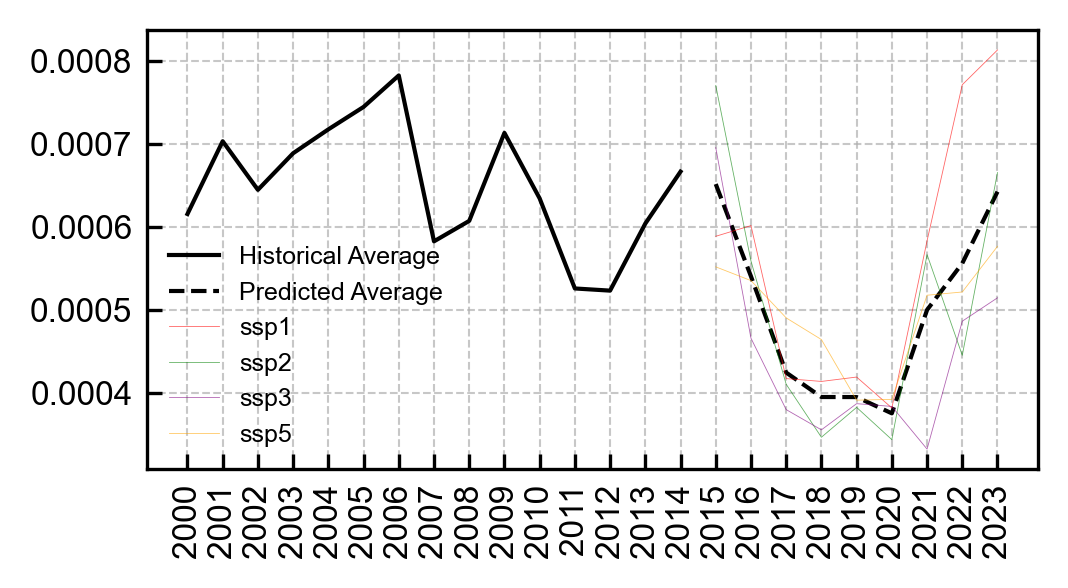

In [7]:
# exam the weather data
import seaborn as sns
import matplotlib.pyplot as plt


import numpy as np
import matplotlib.pyplot as plt

# Assuming features_flattened_train and other datasets are already defined

# Set global font to Arial
plt.rcParams['font.family'] = 'Arial'

# Create a figure with specified size
fig, ax = plt.subplots(figsize=(3.6, 2))  # Width and height in inches

# Plot the training data line
train_line = (features_flattened_train[:, 32:33].reshape(17, 15).sum(axis=0) +
              features_flattened_train[:, 31:32].reshape(17, 15).sum(axis=0) +
              features_flattened_train[:, 34:35].reshape(17, 15).sum(axis=0))
ax.plot(range(0, 15), train_line, label='Historical Average', linestyle='-', color='black', linewidth=1)

# Define the range for the x-axis
x_range = range(15, 24)

# Calculate the sum of the specified slices for each dataset
line1 = (features_flattened_test_ssp1[:, 32:33].reshape(17, 9).sum(axis=0) +
         features_flattened_test_ssp1[:, 31:32].reshape(17, 9).sum(axis=0) +
         features_flattened_test_ssp1[:, 34:35].reshape(17, 9).sum(axis=0))

line2 = (features_flattened_test_ssp2[:, 32:33].reshape(17, 9).sum(axis=0) +
         features_flattened_test_ssp2[:, 31:32].reshape(17, 9).sum(axis=0) +
         features_flattened_test_ssp2[:, 34:35].reshape(17, 9).sum(axis=0))

line3 = (features_flattened_test_ssp3[:, 32:33].reshape(17, 9).sum(axis=0) +
         features_flattened_test_ssp3[:, 31:32].reshape(17, 9).sum(axis=0) +
         features_flattened_test_ssp3[:, 34:35].reshape(17, 9).sum(axis=0))

line4 = (features_flattened_test_ssp5[:, 32:33].reshape(17, 9).sum(axis=0) +
         features_flattened_test_ssp5[:, 31:32].reshape(17, 9).sum(axis=0) +
         features_flattened_test_ssp5[:, 34:35].reshape(17, 9).sum(axis=0))

# Stack the lines into a 2D array for averaging
lines_stack = np.vstack([line1, line2, line3, line4])

# Calculate the average across the stacked lines
average_line = np.mean(lines_stack, axis=0)

# Plot the average line
ax.plot(x_range, average_line, label='Predicted Average', linestyle='--', color='black', linewidth=1)

# Optionally, plot the individual lines for reference
ax.plot(x_range, line1, label='ssp1', linestyle='-', color='red', linewidth=0.2, alpha=0.6)
ax.plot(x_range, line2, label='ssp2', linestyle='-', color='green', linewidth=0.2, alpha=0.6)
ax.plot(x_range, line3, label='ssp3', linestyle='-', color='purple', linewidth=0.2, alpha=0.6)
ax.plot(x_range, line4, label='ssp5', linestyle='-', color='orange', linewidth=0.2, alpha=0.6)

# Combine the x-tick ranges from both plots
combined_x_range = list(range(0, 15)) + list(x_range)

# Set x-ticks to show all values
years = np.arange(2000, 2024)
ax.set_xticks(np.arange(len(years)))
ax.set_xticklabels(years, rotation=90, ha='center')

# Add labels and legend
# ax.set_xlabel('X-axis Label (units)', fontsize=12)
# ax.set_ylabel('Y-axis Label (units)', fontsize=12)
# ax.set_title('Average of Four Lines', fontsize=14, weight='bold')
ax.legend(fontsize=6, frameon=False)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Adjust layout for better spacing
fig.tight_layout()

# Save the figure in high resolution
plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/weather_figure.tif', dpi=300, bbox_inches='tight')
plt.show()



In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

# 1. Correlation Coefficients
def correlation_coefficients(X, y):
    corrs = []
    for i in range(X.shape[1]):
        corr, _ = pearsonr(X[:, i], y)
        corrs.append(abs(corr))  # Take absolute value to focus on strength, not direction
    return np.array(corrs)

correlation_importances = correlation_coefficients(X_train, y_train)


# 2. Random Forest Feature Importance
rfc = RandomForestRegressor(n_estimators=1000, random_state=42)
rfc.fit(X_train, y_train)
rfc_importances = rfc.feature_importances_

# 3. Aggregate Feature Importance
# Normalize each method's importances to make them comparable
correlation_importances = correlation_importances / np.sum(correlation_importances)
rfc_importances = rfc_importances / np.sum(rfc_importances)

# Average the importances
overall_importance = np.mean([correlation_importances, rfc_importances], axis=0)


# Months of the year
months = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

# Define feature categories
categories = ['pr', 'huss', 'mrro', 'sfcWind', 'tas', 'clt', 'evspsbl', 'mrsos']

# Generate feature names
features = [f'{category}_{month}' for category in categories for month in months]


importance_df = pd.DataFrame({'Feature': features, 'Correlation Importance': correlation_importances,
                              'RFC Importance': rfc_importances,
                              'Overall Importance': overall_importance})




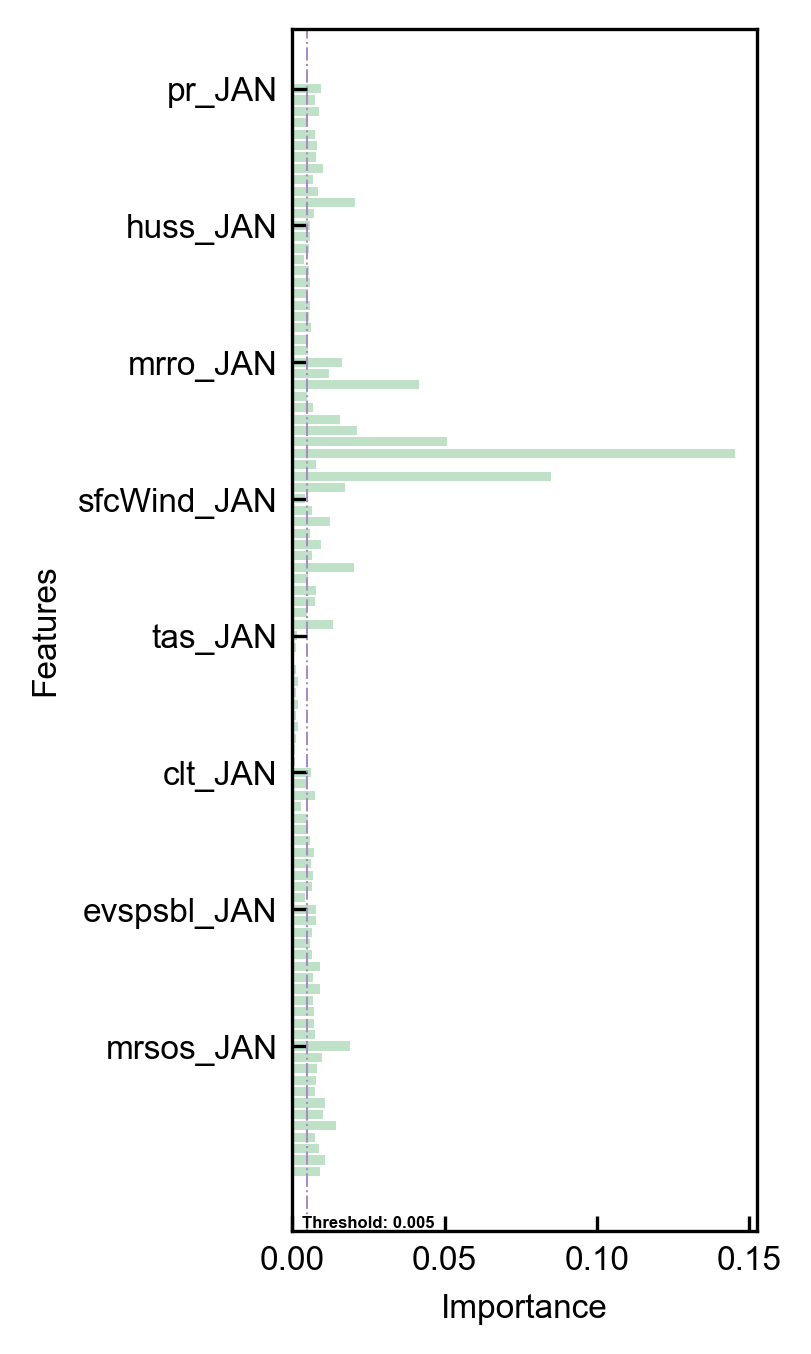

Selected 77 important features:
['pr_JAN' 'pr_FEB' 'pr_MAR' 'pr_APR' 'pr_MAY' 'pr_JUN' 'pr_JUL' 'pr_AUG'
 'pr_SEP' 'pr_OCT' 'pr_NOV' 'pr_DEC' 'huss_JAN' 'huss_FEB' 'huss_MAR'
 'huss_MAY' 'huss_JUN' 'huss_JUL' 'huss_AUG' 'huss_SEP' 'huss_OCT'
 'huss_NOV' 'huss_DEC' 'mrro_JAN' 'mrro_FEB' 'mrro_MAR' 'mrro_MAY'
 'mrro_JUN' 'mrro_JUL' 'mrro_AUG' 'mrro_SEP' 'mrro_OCT' 'mrro_NOV'
 'mrro_DEC' 'sfcWind_FEB' 'sfcWind_MAR' 'sfcWind_APR' 'sfcWind_MAY'
 'sfcWind_JUN' 'sfcWind_JUL' 'sfcWind_AUG' 'sfcWind_SEP' 'sfcWind_OCT'
 'sfcWind_DEC' 'clt_JAN' 'clt_FEB' 'clt_MAR' 'clt_MAY' 'clt_JUL' 'clt_AUG'
 'clt_SEP' 'clt_OCT' 'clt_NOV' 'evspsbl_JAN' 'evspsbl_FEB' 'evspsbl_MAR'
 'evspsbl_APR' 'evspsbl_MAY' 'evspsbl_JUN' 'evspsbl_JUL' 'evspsbl_AUG'
 'evspsbl_SEP' 'evspsbl_OCT' 'evspsbl_NOV' 'evspsbl_DEC' 'mrsos_JAN'
 'mrsos_FEB' 'mrsos_MAR' 'mrsos_APR' 'mrsos_MAY' 'mrsos_JUN' 'mrsos_JUL'
 'mrsos_AUG' 'mrsos_SEP' 'mrsos_OCT' 'mrsos_NOV' 'mrsos_DEC']


In [14]:
# plot the importance and define the threshold

# Plot the overall feature importances
fig, ax = plt.subplots(figsize=(2, 5.2))

plt.barh(importance_df['Feature'], importance_df['Overall Importance'], color='#A4D5B1', alpha=0.7)
plt.xlabel('Importance')
plt.ylabel('Features')
ax.axvline(x=0.005, color='#A88EC0', linestyle='-.', linewidth=0.5)
ax.text(0.025, ax.get_ylim()[1], 'Threshold: 0.005', color='k', ha='center', va='bottom',fontweight='bold' , fontsize=4, rotation=0)

yticks=importance_df['Feature']
ax.set_yticks(range(0, len(yticks), 12))
# ax.set_yticklabels(yticks[::6], fontsize=6, rotation=0)
# ax.set_yticklabels([])
# plt.title('Overall Feature Importances')
plt.gca().invert_yaxis()

plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/figure_Fimportance.tiff',dpi=300, bbox_inches='tight')
plt.show()

# Define a threshold to select important features
importance_threshold = 0.005

# Select features above the threshold
important_features = importance_df[importance_df['Overall Importance'] > importance_threshold]['Feature'].values


print(f'Selected {len(important_features)} important features:')
print(important_features)

In [15]:
!pip install scikeras

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.compose import TransformedTargetRegressor

# Map the important feature names back to their indices
important_indices = [features.index(feature) for feature in important_features]


# Fixed Keras model with positive output constraint
def build_keras_mlp(input_dim):
    model = Sequential([
        Dense(50, input_dim=input_dim, activation='relu'),
        Dense(50, activation='relu'),
        Dense(1, activation='relu')
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Improved KerasRegressor with sklearn compatibility
class PositiveKerasRegressor(RegressorMixin,BaseEstimator):
    def __init__(self, input_dim, epochs=100, batch_size=32, verbose=0):
        self.input_dim = input_dim  # Changed from input_shape to input_dim
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.model = None

    def fit(self, X, y):
        self.model = build_keras_mlp(self.input_dim)
        self.model.fit(X, y,
                      epochs=self.epochs,
                      batch_size=self.batch_size,
                      verbose=self.verbose,
                      validation_split=0.1)  # Added validation split
        return self

    def predict(self, X):
        if self.model is None:
            raise RuntimeError("Model must be fitted before prediction")
        predictions = self.model.predict(X)
        return predictions.flatten()

# Calculate input dimension based on important features
input_dim = len(important_indices)  # Changed from shape[0] to use important_indices

# Corrected pipeline definitions using Pipeline instead of make_pipeline
mlp0 = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', PositiveKerasRegressor(input_dim=input_dim, epochs=100, batch_size=32, verbose=0))
])

mlp1 = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', PositiveKerasRegressor(input_dim=input_dim, epochs=100, batch_size=32, verbose=0))
])

mlp2 = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', PositiveKerasRegressor(input_dim=input_dim, epochs=100, batch_size=32, verbose=0))
])

# Create stacking regressor
meta_model = LinearRegression(positive=True, fit_intercept=False)
base_models = [('mlp0', mlp0), ('mlp1', mlp1), ('mlp2', mlp2)]

stacking_regressor = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    passthrough=False,
    cv=5,
    n_jobs=-1  # Added parallel processing
)

# Train the model
stacking_regressor.fit(X_train[:, important_indices], y_train)




StackingRegressor(cv=5,
                  estimators=[('mlp0',
                               Pipeline(steps=[('scaler', StandardScaler()),
                                               ('mlp',
                                                PositiveKerasRegressor(input_dim=77))])),
                              ('mlp1',
                               Pipeline(steps=[('scaler', StandardScaler()),
                                               ('mlp',
                                                PositiveKerasRegressor(input_dim=77))])),
                              ('mlp2',
                               Pipeline(steps=[('scaler', StandardScaler()),
                                               ('mlp',
                                                PositiveKerasRegressor(input_dim=77))]))],
                  final_estimator=LinearRegression(fit_intercept=False,
                                                   positive=True),
                  n_jobs=-1)

In [18]:
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Define parameter grids for each model
param_grid_mlp = {
    'mlp__hidden_layer_sizes': [(50,), (50, 50)],
    'mlp__solver': ['adam'],
    'mlp__alpha': [0.0001, 0.001],
    'mlp__learning_rate': ['constant', 'adaptive']
}

param_grid_rf = {
    'n_estimators': [500],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4]
}

param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance'],
    'knn__algorithm': ['auto']
}

# Define MLP Pipeline
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(max_iter=1000, random_state=42))
])

# Define KNN Pipeline (with scaler)
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])

# Initialize models
rf = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV objects
gscv_mlp = GridSearchCV(mlp_pipeline, param_grid_mlp, cv=5, scoring='r2', n_jobs=-1)
gscv_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='r2', n_jobs=-1)
gscv_knn = GridSearchCV(knn_pipeline, param_grid_knn, cv=5, scoring='r2', n_jobs=-1)

# Fit models (assuming X_train, y_train, and important_indices are defined)
gscv_mlp.fit(X_train[:, important_indices], y_train)
gscv_rf.fit(X_train[:, important_indices], y_train)
gscv_knn.fit(X_train[:, important_indices], y_train)

models = [gscv_mlp.best_estimator_, gscv_rf.best_estimator_, gscv_knn.best_estimator_]

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Scenario 1:
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Scenario 2:
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
<ipython-input-19-6b7df867fb81>:34: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)
/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


...

/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Scenario 4:
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
<ipython-input-19-6b7df867fb81>:34: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)
/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
<ipython-input-19-6b7df867fb81>:34: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)


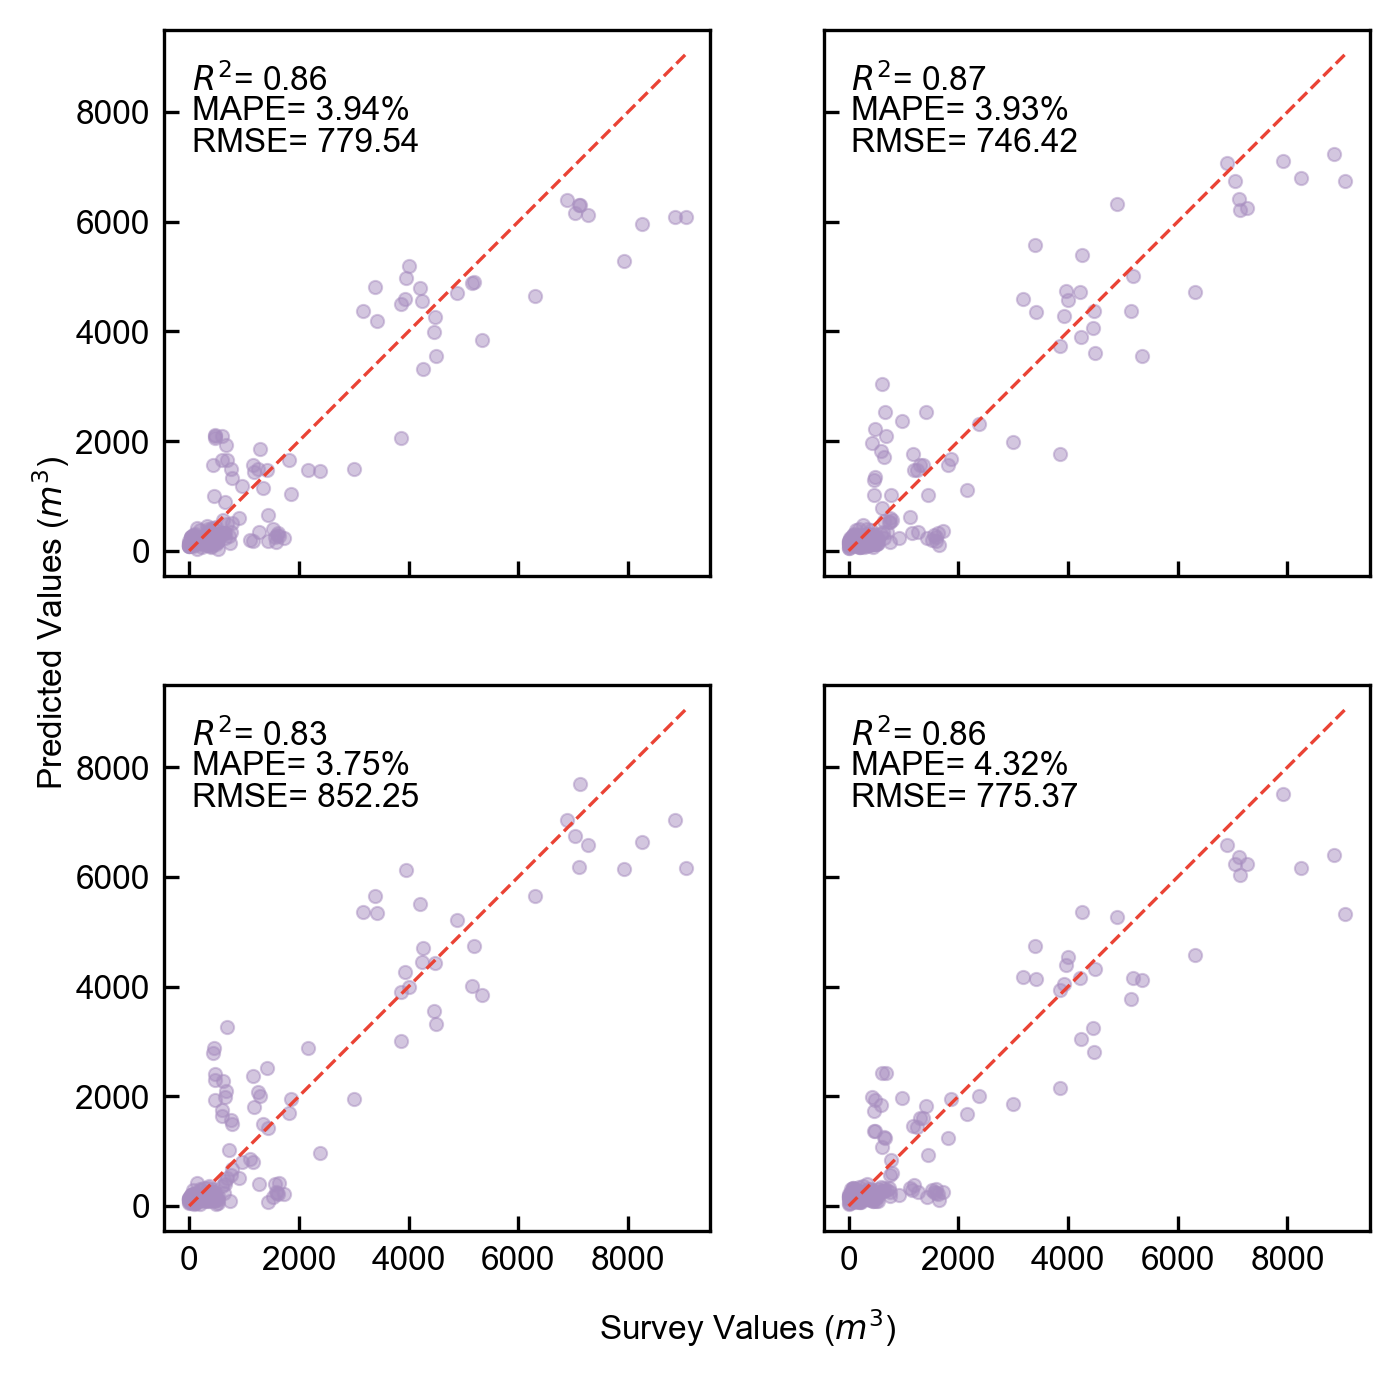

Scenario 1:
Scenario 2:
Scenario 3:
Scenario 4:


<ipython-input-19-6b7df867fb81>:79: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)
<ipython-input-19-6b7df867fb81>:79: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)
<ipython-input-19-6b7df867fb81>:79: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)
<ipython-input-19-6b7df867fb81>:79: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt st

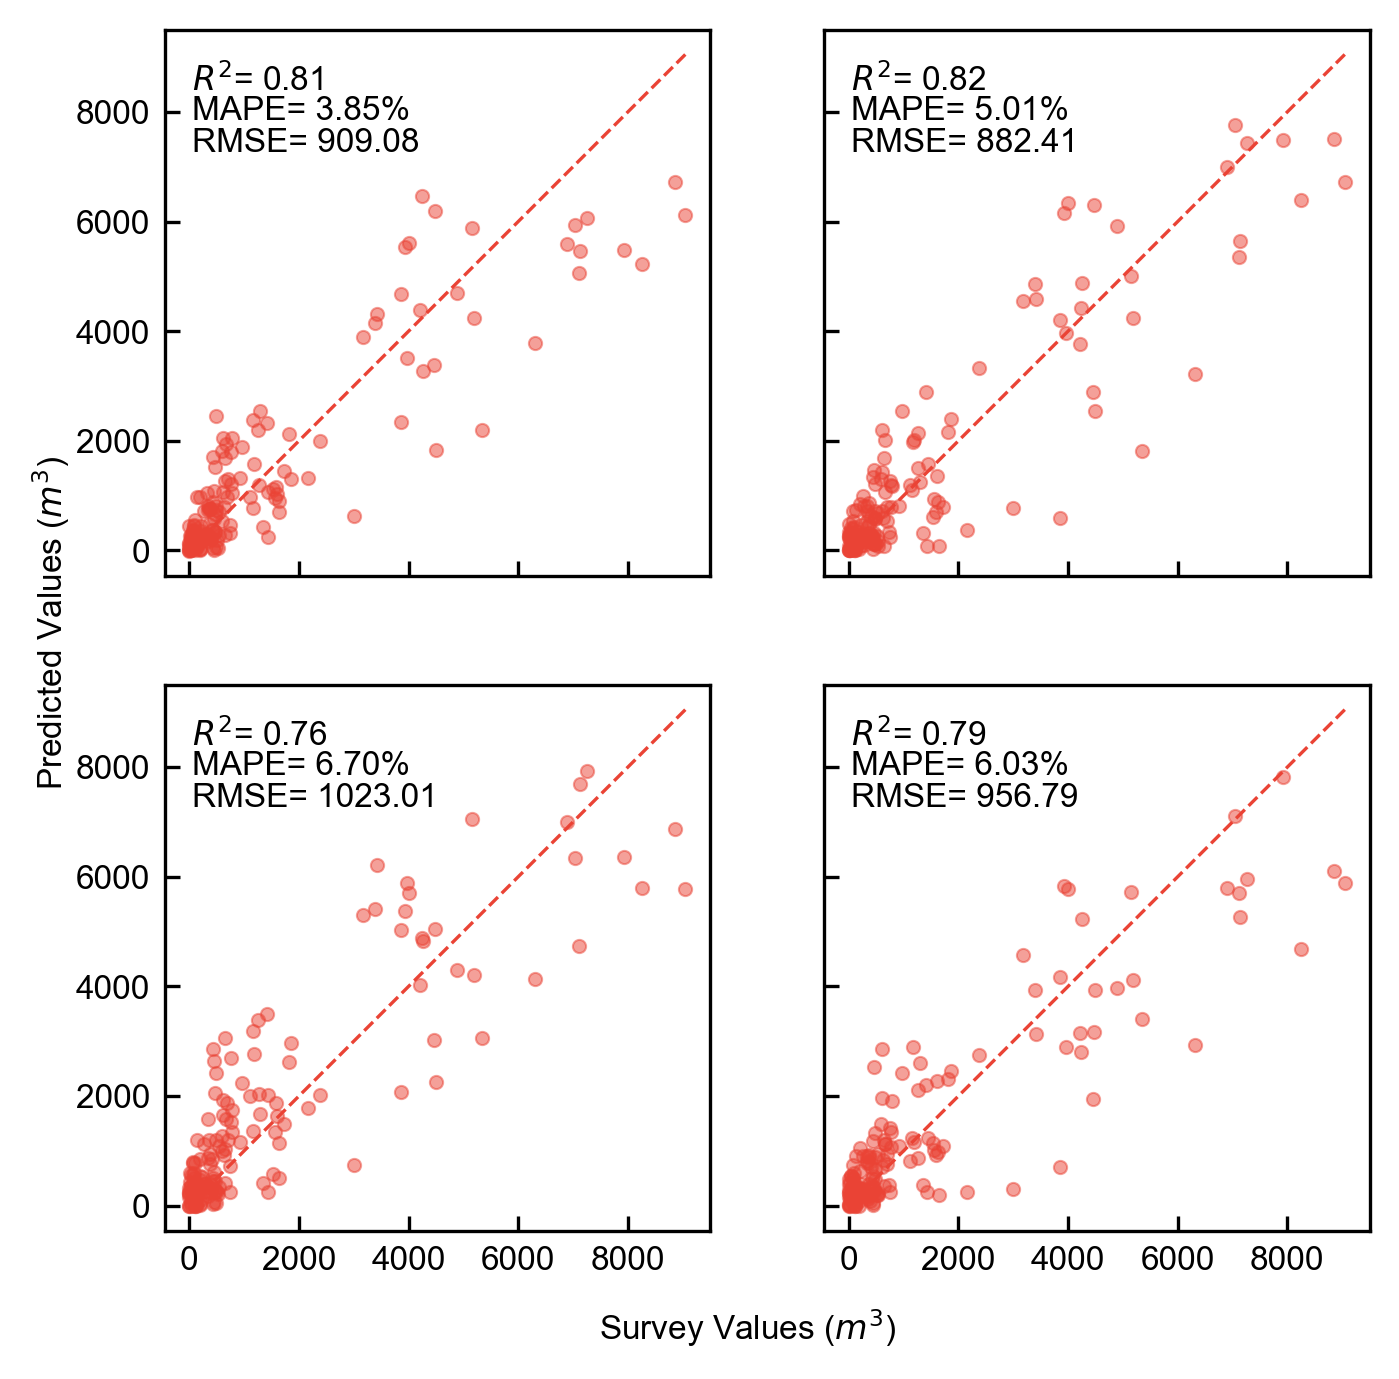

Scenario 1:
Scenario 2:
Scenario 3:

<ipython-input-19-6b7df867fb81>:79: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)
<ipython-input-19-6b7df867fb81>:79: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)
<ipython-input-19-6b7df867fb81>:79: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)



Scenario 4:


<ipython-input-19-6b7df867fb81>:79: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)


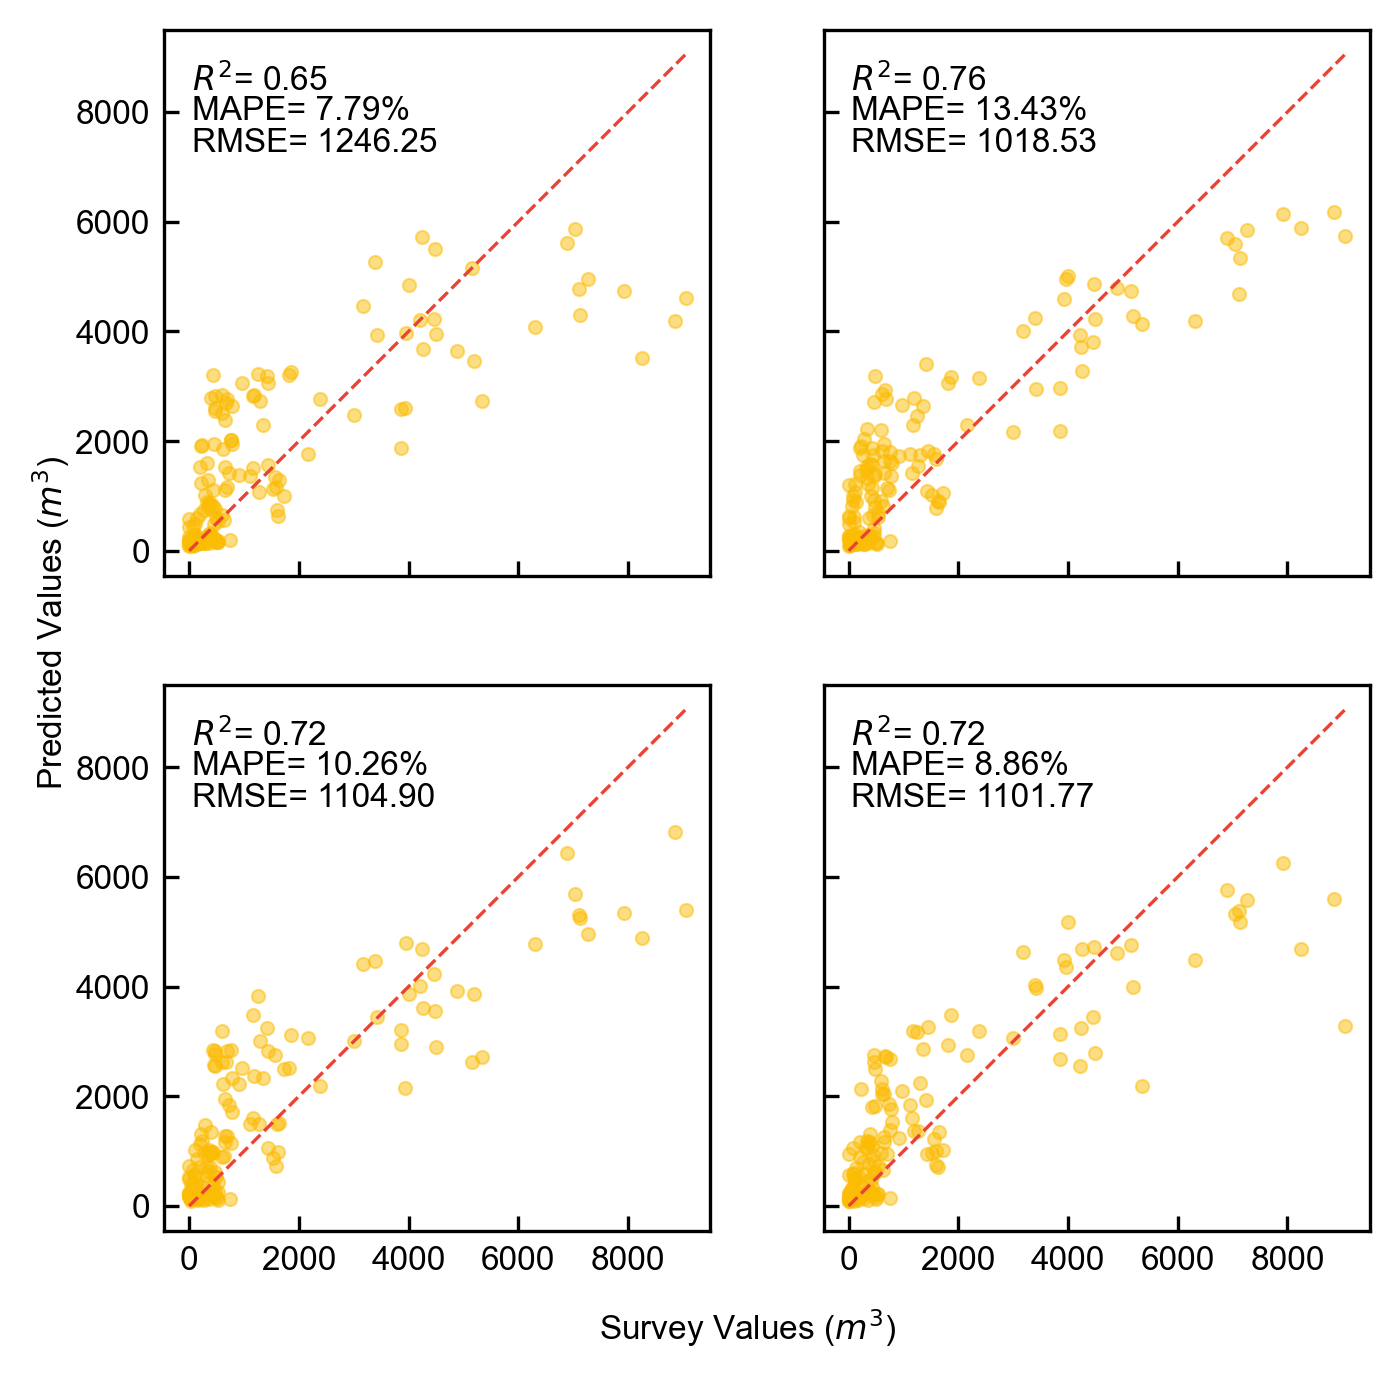

Scenario 1:
Scenario 2:
Scenario 3:
Scenario 4:


<ipython-input-19-6b7df867fb81>:79: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)
<ipython-input-19-6b7df867fb81>:79: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)
<ipython-input-19-6b7df867fb81>:79: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)
<ipython-input-19-6b7df867fb81>:79: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt st

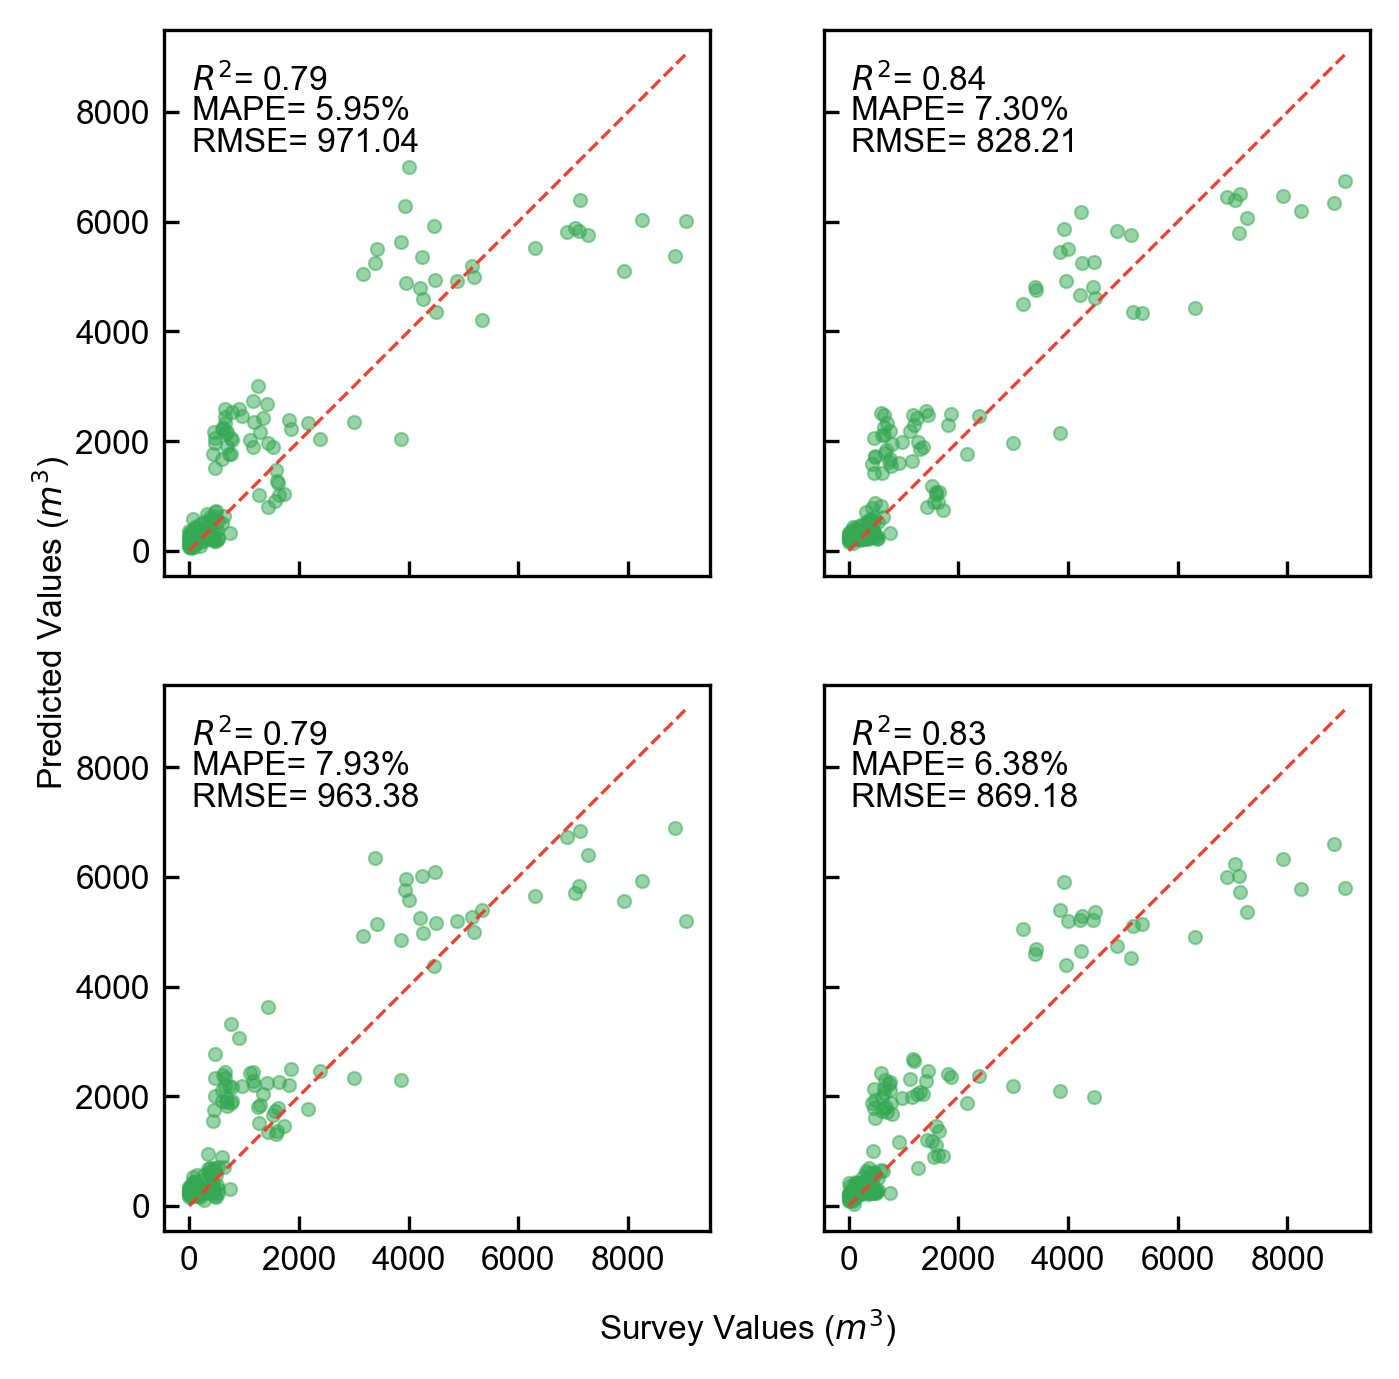

In [19]:
# SCATTER PLOT THE prediction results
# Make predictions on each test set in the list and evaluate
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_squared_error


fig, axs = plt.subplots(2, 2, figsize=(5.2, 5.2), sharey=True, sharex=True)

# Loop through each test scenario and predict
for i, X_test in enumerate(list_features_flattened_test):
    print(f"Scenario {i+1}:")

    # Predict using the trained stacking model
    y_pred = stacking_regressor.predict(X_test[:, important_indices])

    # Calculate the R^2 score
    r2 = r2_score(y_test, y_pred)

    # Calculate MAPE (Mean Absolute Percentage Error)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    # Calculate RMSE (Root Mean Squared Error)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Example visualization of predictions vs actual values for each test set
    ax = axs[i // 2, i % 2]
    ax.scatter(y_test, y_pred, marker='o', s=10, color='#A88EC0', linewidth=0.5, alpha=0.5)

    # Annotate the plot with R², MAPE, and RMSE
    ax.text(0.05, 0.94, f'$R^2$= {r2:.2f}', transform=ax.transAxes, ha='left', va='top')
    ax.text(0.05, 0.88, f'MAPE= {mape:.2f}%', transform=ax.transAxes, ha='left', va='top')
    ax.text(0.05, 0.82, f'RMSE= {rmse:.2f}', transform=ax.transAxes, ha='left', va='top')

    # Plot the 1:1 line for reference
    ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)
    ax.set_aspect('equal', 'box')

# Set common labels
fig.text(0.5, 0.04, 'Survey Values ($m^3$)', ha='center')
fig.text(0.04, 0.5, 'Predicted Values ($m^3$)', va='center', rotation='vertical')

plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/figure_scatter_plot.tiff',dpi=300, bbox_inches='tight')

plt.show()



models = [gscv_mlp.best_estimator_, gscv_rf.best_estimator_, gscv_knn.best_estimator_]
colors = ['#EA4335','#FBBC04','#34A853']
for model, color in zip(models, colors):

  fig, axs = plt.subplots(2, 2, figsize=(5.2, 5.2), sharey=True, sharex=True)

  # Loop through each test scenario and predict
  for i, X_test in enumerate(list_features_flattened_test):
      print(f"Scenario {i+1}:")

      # Predict using the trained stacking model
      y_pred_sub = model.predict(X_test[:, important_indices])

      # Calculate the R^2 score
      r2 = r2_score(y_test, y_pred_sub)

      # Calculate MAPE (Mean Absolute Percentage Error)
      mape = mean_absolute_percentage_error(y_test, y_pred_sub)

      # Calculate RMSE (Root Mean Squared Error)
      rmse = np.sqrt(mean_squared_error(y_test, y_pred_sub))

      # Example visualization of predictions vs actual values for each test set
      ax = axs[i // 2, i % 2]
      ax.scatter(y_test, y_pred_sub, marker='o', s=10, color=color, linewidth=0.5, alpha=0.5)

      # Annotate the plot with R², MAPE, and RMSE
      ax.text(0.05, 0.94, f'$R^2$= {r2:.2f}', transform=ax.transAxes, ha='left', va='top')
      ax.text(0.05, 0.88, f'MAPE= {mape:.2f}%', transform=ax.transAxes, ha='left', va='top')
      ax.text(0.05, 0.82, f'RMSE= {rmse:.2f}', transform=ax.transAxes, ha='left', va='top')

      # Plot the 1:1 line for reference
      ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)
      ax.set_aspect('equal', 'box')

  # Set common labels
  fig.text(0.5, 0.04, 'Survey Values ($m^3$)', ha='center')
  fig.text(0.04, 0.5, 'Predicted Values ($m^3$)', va='center', rotation='vertical')

  plt.savefig(f'/content/drive/MyDrive/NU work/Cotton/Figures/figure_scatter_plot_{model}.tiff',dpi=300, bbox_inches='tight')

  plt.show()





In [20]:
list_features_flattened_predict = [features_flattened_predict_ssp1,
                                features_flattened_predict_ssp2,
                                features_flattened_predict_ssp3,
                                features_flattened_predict_ssp5]
base_predictions = {}
for i, features_flattened_predict in enumerate(list_features_flattened_predict):
    base_predictions[i] = stacking_regressor.predict(features_flattened_predict[:, important_indices])

print(base_predictions[i])

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
 1/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
 1/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
 1/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

...

/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
 1/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
[  50.32079841   62.76612892   38.57132326   73.32853041  151.68472587
  242.15114743   55.50504919  106.16155776  141.57266503   91.67195745
  395.80950358  237.78347082  231.75651912  143.866015    345.99035004
  314.97269298  281.15288068  282.42393666  227.43369286  232.65907433
  219.6745494   161.10641209  111.70588015  114.75312684   85.79532735
  224.71551256 6785.16432074 6408.60534479 6161.33832124 7163.36090991
 6872.24015269 6616.20267613 5541.82020061 5974.42862907 5506.31392698
 5977.58344703 6862.904796   6965.10100736 7034.87241749 6826.60094122
 7147.92075589 8034.20930952 7358.5148556  6136.52667586 5796.16710598
 6739.50899926 7222.57488037 6344.87414679 6675.50282954 5820.47972127
 6248.26420587 7466.16797475  206.81147071  235.60111247  352.00056366
  235.01260868  274.98838207  378.59188909  154.45439119  172.92515637
  119.71284494  174.27854553  302.42173287  215.37398001  163.643554

/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


              0            1            2            3            4  \
0    458.664343   317.755862   231.320160   524.227676   651.971944   
1   7044.514079  7256.915224  6187.825816  7709.097897  7318.199379   
2    432.727820   289.737584   358.560752   768.314197   639.077487   
3   2905.851590  3403.758794  3392.187909  3660.516579  3953.125816   
4    312.832598   371.517133   243.596812   264.142088   308.187011   
5    277.099446   340.808386   111.230598   281.671822   460.788684   
6   1929.635317  1910.302450  2946.515286  1349.651359  1790.455042   
7    616.483566   521.205657   556.685184   853.710497   750.421566   
8    617.025451   446.602145   467.814771   801.787682   861.111330   
9    288.304724   264.270375   956.213636   565.384576   474.328765   
10  4628.422124  4792.818837  4812.466996  5971.051629  5652.140263   
11   361.693310   406.627045   347.963194   408.621030   580.018591   
12   744.537354   772.104500  2439.454864   771.878229  1107.186770   
13   2

<ipython-input-21-f7f41c6d543e>:107: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  main_ax.set_xticklabels(['','2024', '2029', '2034', '2039', '2044', '2049'])
<ipython-input-21-f7f41c6d543e>:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


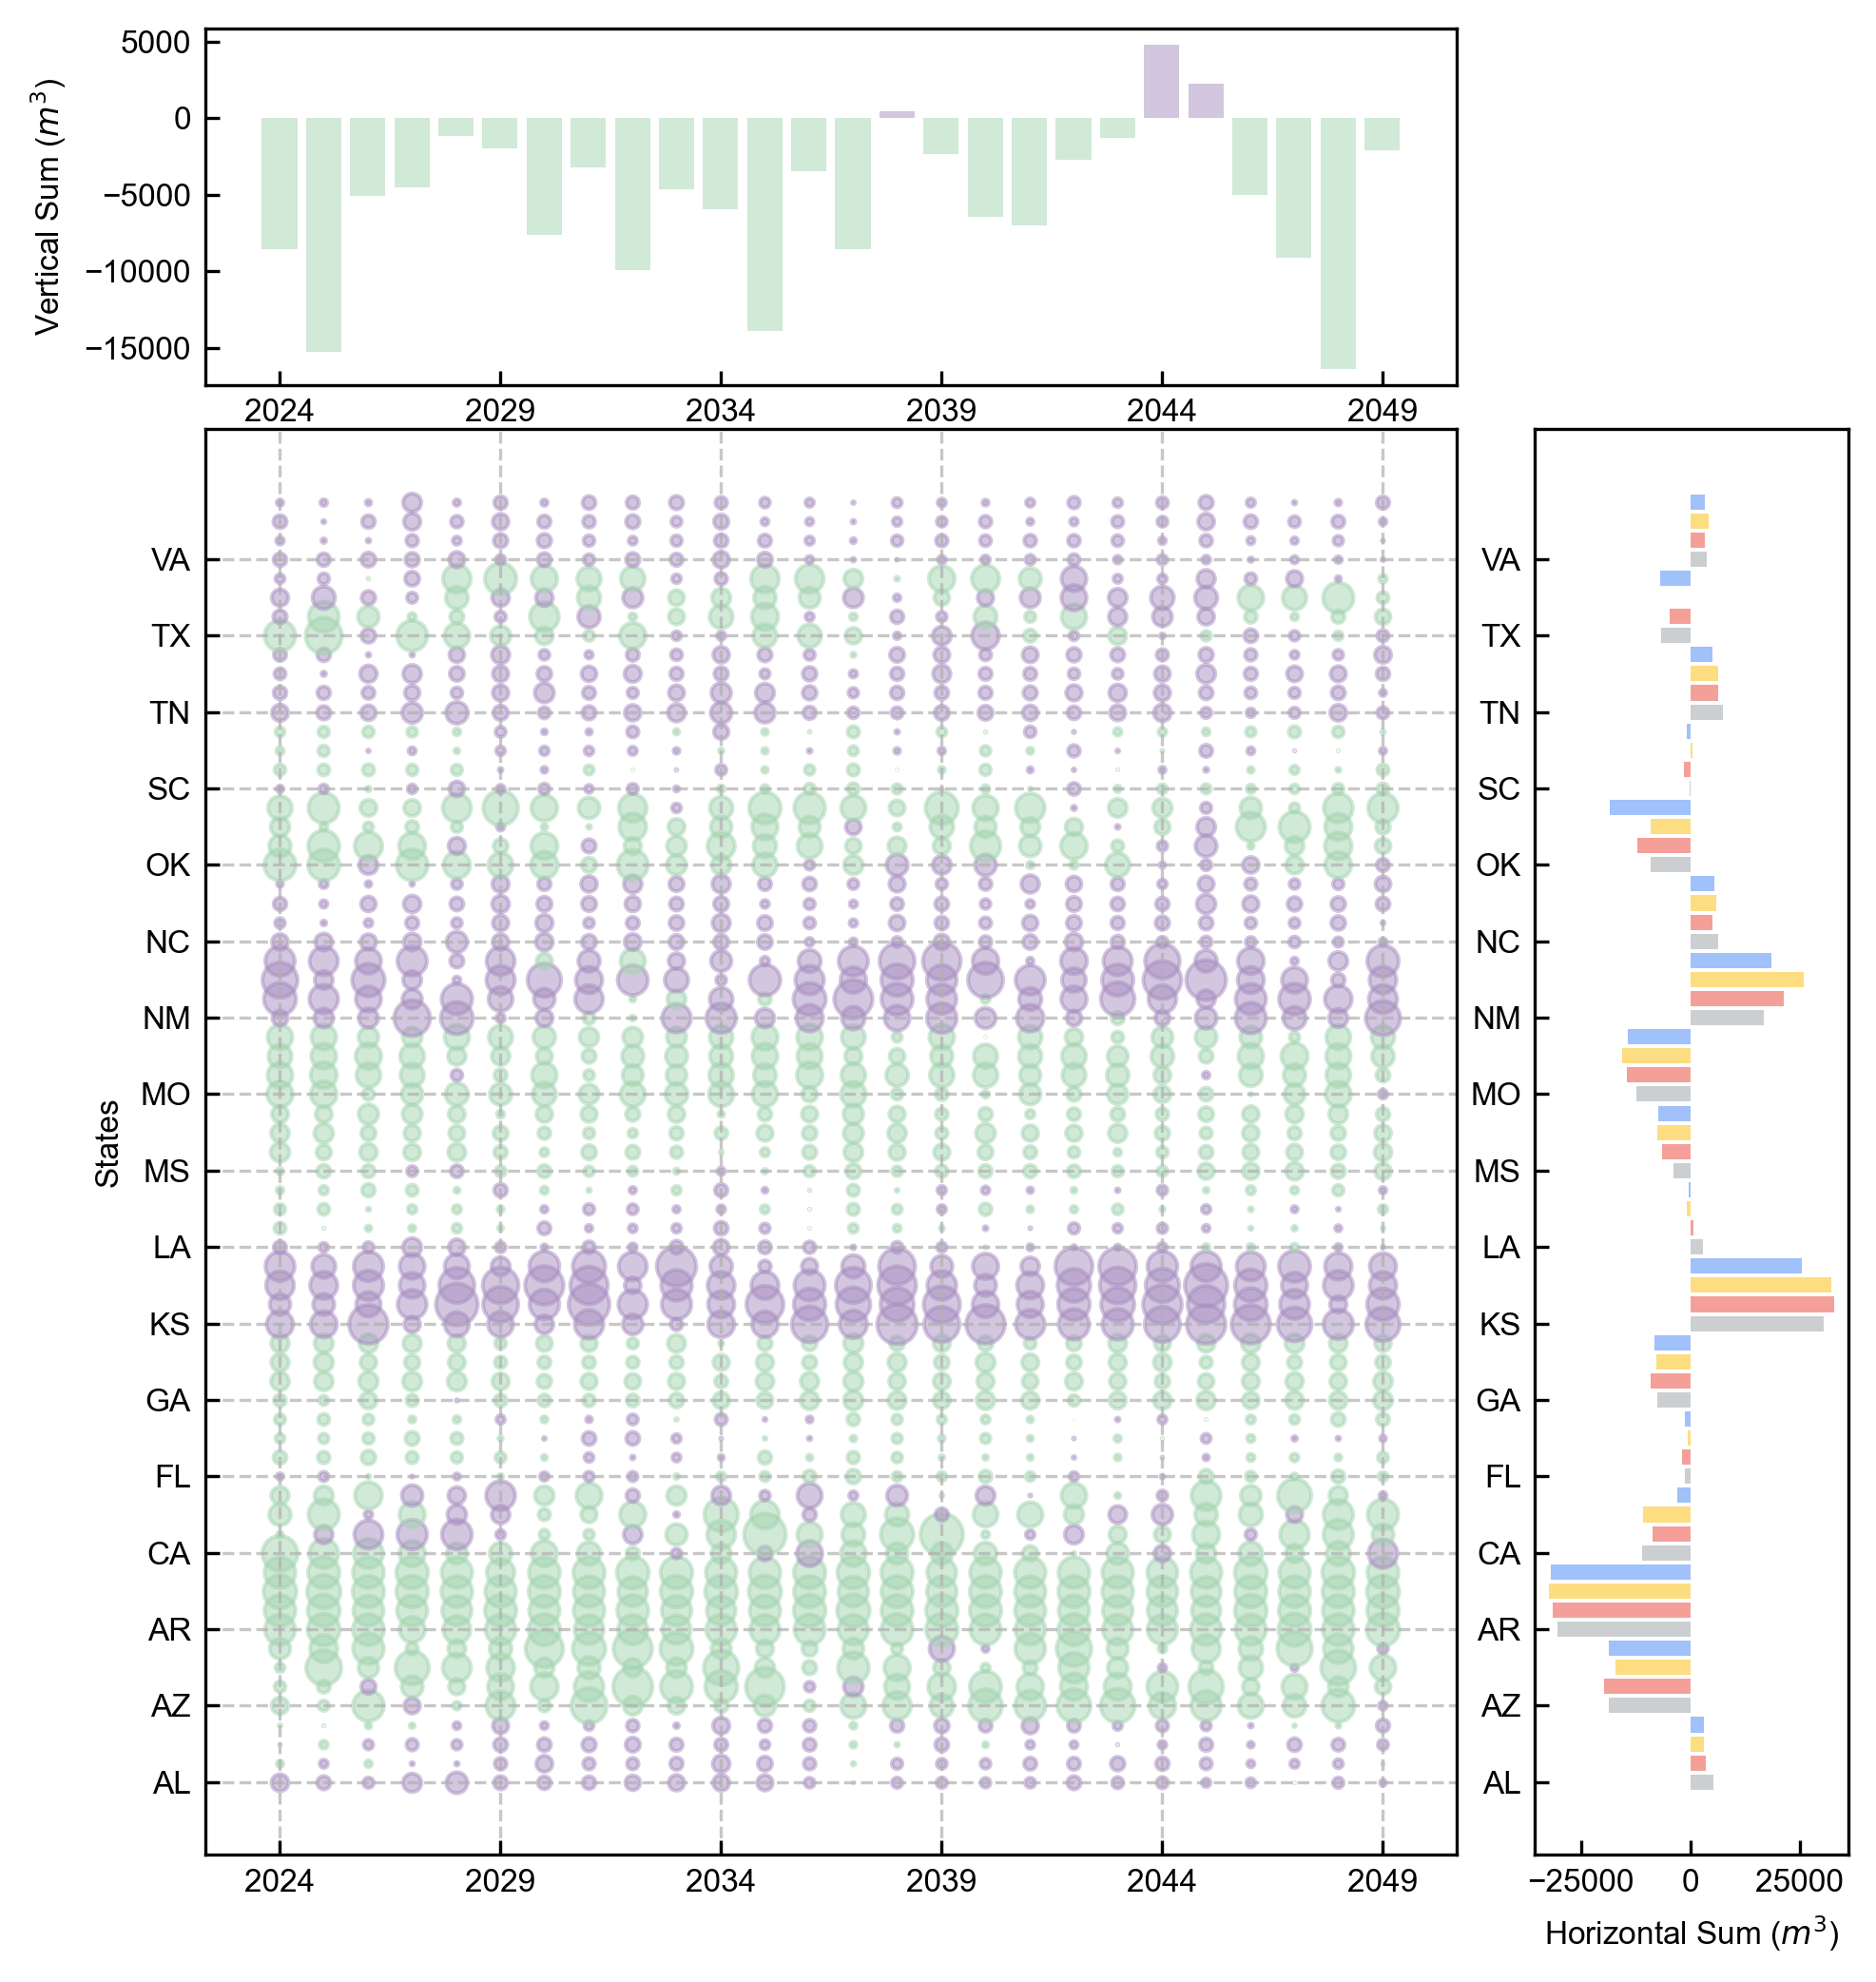

In [21]:
# Reshape the array to shape (17, 26)
# reshaped_data1 = base_predictions[0].reshape(17, 26)
# reshaped_data2 = base_predictions[1].reshape(17, 26)
# reshaped_data3 = base_predictions[2].reshape(17, 26)
# reshaped_data4 = base_predictions[3].reshape(17, 26)

# combined_dataframe_rawprediction = pd.concat([pd.DataFrame(reshaped_data1), pd.DataFrame(reshaped_data2), pd.DataFrame(reshaped_data3), pd.DataFrame(reshaped_data4)], axis=1)
# combined_dataframe_rawprediction.to_excel('/content/drive/MyDrive/NU work/Cotton/Python outputs/predicted_raw_water_consumption.xlsx')
import pandas as pd
import numpy as np

combined_dataframe_rawprediction = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/Python outputs/predicted_raw_water_consumption.xlsx', usecols=range(1,105))

print(combined_dataframe_rawprediction)

m, n = 17, 26  # Shape of each original dataset
cols_per_dataset = n

reshaped_data1= combined_dataframe_rawprediction.iloc[:, :cols_per_dataset].values.reshape(m, n)
reshaped_data2 = combined_dataframe_rawprediction.iloc[:, cols_per_dataset:2*cols_per_dataset].values.reshape(m, n)
reshaped_data3 = combined_dataframe_rawprediction.iloc[:, 2*cols_per_dataset:3*cols_per_dataset].values.reshape(m, n)
reshaped_data4 = combined_dataframe_rawprediction.iloc[:, 3*cols_per_dataset:].values.reshape(m, n)




df_water_history = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/Python outputs/water consumption.xlsx', index_col=0)
# print(df_water_history

df_water_history_average = df_water_history.mean(axis=1)

df1 = pd.DataFrame(reshaped_data1-(np.array(df_water_history_average).reshape(17,1)), index=['AL', 'AZ', 'AR', 'CA', 'FL', 'GA', 'KS', 'LA', 'MS', 'MO', 'NM', 'NC', 'OK', 'SC', 'TN', 'TX', 'VA'])
df2 = pd.DataFrame(reshaped_data2-(np.array(df_water_history_average).reshape(17,1)), index=['AL', 'AZ', 'AR', 'CA', 'FL', 'GA', 'KS', 'LA', 'MS', 'MO', 'NM', 'NC', 'OK', 'SC', 'TN', 'TX', 'VA'])
df3 = pd.DataFrame(reshaped_data3-(np.array(df_water_history_average).reshape(17,1)), index=['AL', 'AZ', 'AR', 'CA', 'FL', 'GA', 'KS', 'LA', 'MS', 'MO', 'NM', 'NC', 'OK', 'SC', 'TN', 'TX', 'VA'])
df4 = pd.DataFrame(reshaped_data4-(np.array(df_water_history_average).reshape(17,1)), index=['AL', 'AZ', 'AR', 'CA', 'FL', 'GA', 'KS', 'LA', 'MS', 'MO', 'NM', 'NC', 'OK', 'SC', 'TN', 'TX', 'VA'])


# List to store interleaved rows
interleaved_rows = []

# Iterate through the rows using zip
for i in range(len(df1)):
    interleaved_rows.append(df1.iloc[i])
    interleaved_rows.append(df2.iloc[i])
    interleaved_rows.append(df3.iloc[i])
    interleaved_rows.append(df4.iloc[i])


# List of states
state = ['AL', 'AZ', 'AR', 'CA', 'FL', 'GA', 'KS', 'LA', 'MS', 'MO', 'NM', 'NC', 'OK', 'SC', 'TN', 'TX', 'VA']

# List of scenarios
sce = ['', 'SSP2', 'SSP3', 'SSP5']

# Generate index names
new_index = [f'{st}{sc}' for st in state for sc in sce]

# Combine the list into a final DataFrame
df_combined = pd.DataFrame(interleaved_rows).reset_index(drop=True)
df_combined.index = new_index
df_combined.to_excel('/content/drive/MyDrive/NU work/Cotton/Python outputs/predicted_water_consumption.xlsx')

# Calculate row and column sums
row_sums = df_combined.sum(axis=1)  # Sum horizontally
col_sums = df_combined.sum(axis=0)  # Sum vertically


#### plot
fig = plt.figure(figsize=(7.2, 8))
divider = fig.add_gridspec(2, 2,  width_ratios=(4, 1),height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.1, hspace=0.05)

main_ax = fig.add_subplot(divider[1,0])
# Iterate through the DataFrame to plot each bubble
for index, row in df_combined.iterrows():
    for col in df_combined.columns:
        value = row[col]
        # Choose color based on whether the value is positive or negative
        color = '#A88EC0' if value > 0 else '#A4D5B1'
        # Plot the bubble
        main_ax.scatter(col, index, s=abs(value) / 20, color=color, alpha=0.5)


colors = ['#9AA0A6', '#EA4335', '#FBBC04', '#4285F4']
# Row sums (plotted to the right of the main plot)
row_sum_ax = fig.add_subplot(divider[1, 1], sharey=main_ax)
row_sum_ax.barh(df_combined.index,row_sums, color=colors, alpha=0.5)
row_sum_ax.set_xlabel('Horizontal Sum ($m^3$)')
# row_sum_ax.invert_xaxis()
# row_sum_ax.invert_yaxis()
# row_sum_ax.set_xlim(0, row_sums.max() * 1.1)  # Adjust limits

# Column sums (plotted above the main plot)
col_sum_ax = fig.add_subplot(divider[0,0], sharex=main_ax)
# Determine the color for each bar: red for positive, blue for negative
bar_colors = ['#A88EC0' if value > 0 else '#A4D5B1' for value in col_sums]

col_sum_ax.bar(df_combined.columns, col_sums,  color=bar_colors, alpha=0.5)
# col_sum_ax.set_ylim(0, col_sums.max() * 1.1)  # Adjust limits
col_sum_ax.set_ylabel('Vertical Sum ($m^3$)')

yticks = range(0, len(df_combined), 4)
main_ax.set_yticks(yticks)
main_ax.set_yticklabels(df_combined.index[yticks])

main_ax.set_xticklabels(['','2024', '2029', '2034', '2039', '2044', '2049'])
main_ax.set_ylabel('States')
# row_sum_ax.set_yticklabels([])
# # Add labels and title
# ax.set_xlabel('Columns')
# ax.set_ylabel('States')
# ax.set_title('Bubble Chart of Reshaped Data')

# Show grid for better readability
main_ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/figure_predictedbubble.tiff',dpi=300, bbox_inches='tight')
# Display the plot
plt.show()

             0            1            2            3            4   \
VA   125.138106    61.572511    91.488471   128.197348    97.876320   
AL   -27.260720    18.610967    -7.920043    62.264972   -23.911673   
NC   112.440355    20.515268    69.718017   182.427968   124.898867   
SC  -115.102235  -141.876772   -72.945738   -50.435018   -67.839513   
FL  -194.349361  -173.951124  -181.333715  -178.617975  -150.056152   
GA  -382.679411  -408.517958  -361.712342  -337.133933  -385.840654   
TN   101.467915   115.043240   154.543166   201.394397    84.237119   
LA  -259.369391  -140.933153   -23.744398  -144.172454  -216.091611   
MS  -534.794968  -427.283907  -370.340936  -420.849916  -503.225764   
MO  -880.641815  -874.126587  -747.201103  -811.174013   -16.486482   
AR -1386.032925 -1380.512084 -1171.565913 -1329.320795 -1280.905669   
KS   480.758092   622.747900   609.961420   950.656199  2144.300224   
OK  -715.372590 -1249.209727 -1141.969910 -1007.807323   286.568930   
TX   1

<ipython-input-22-7ca378ad7a90>:126: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


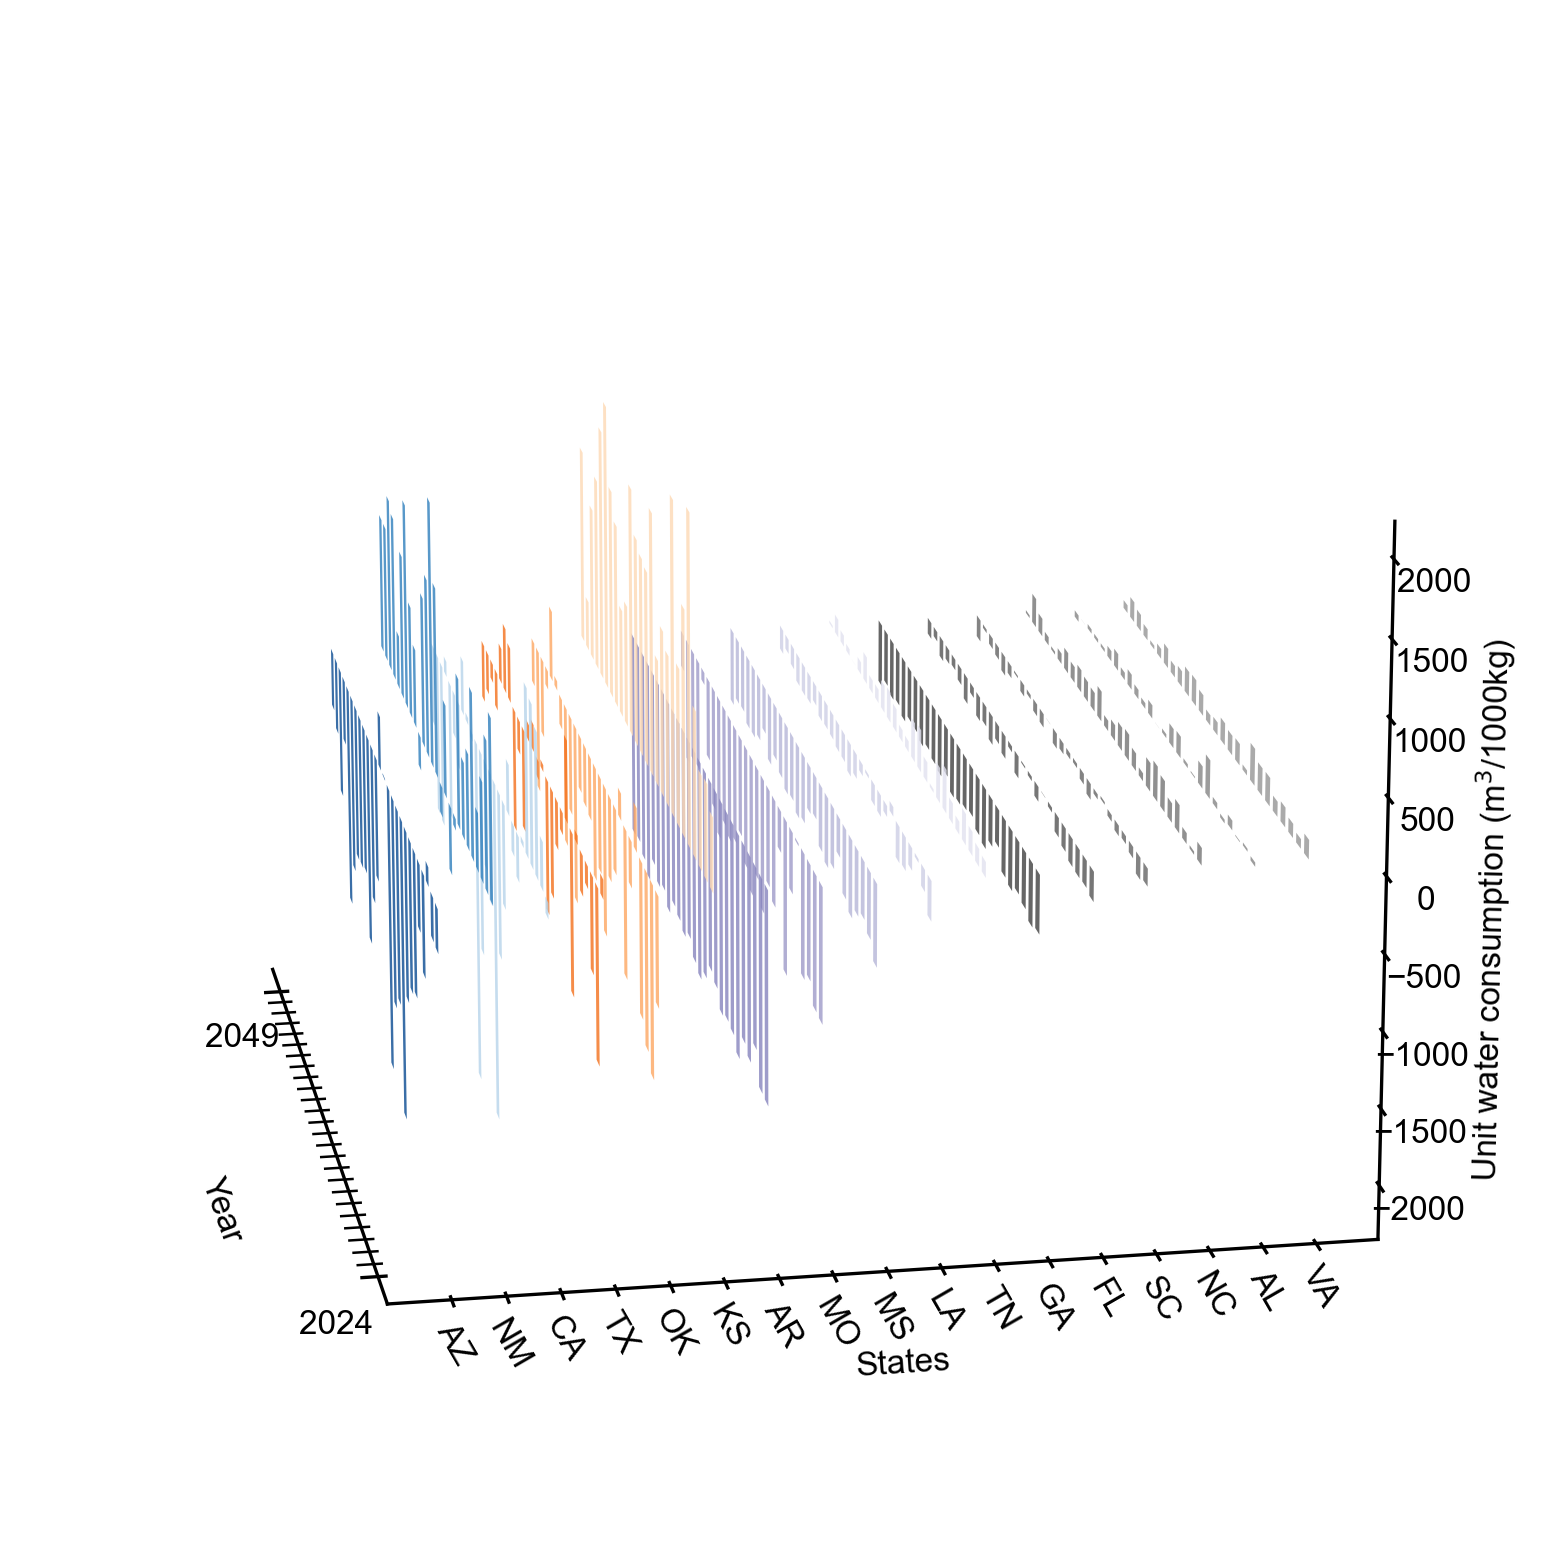

In [22]:
# Reshape the array to shape (17, 26)
reshaped_data = base_predictions[1].reshape(17, 26)

df_water_history = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/Python outputs/water consumption.xlsx', index_col=0)
# print(df_water_history

df_water_history_average = df_water_history.mean(axis=1)

reshaped_data = pd.DataFrame(reshaped_data-(np.array(df_water_history_average).reshape(17,1)), index=['AL', 'AZ', 'AR', 'CA', 'FL', 'GA', 'KS', 'LA', 'MS', 'MO', 'NM', 'NC', 'OK', 'SC', 'TN', 'TX', 'VA'])

# from IPython.display import display
# import ipywidgets as widgets

# display(widgets.HTML("<script src='https://cdnjs.cloudflare.com/ajax/libs/require.js/2.3.4/require.min.js'></script>"))
# # !pip install ipympl
# %matplotlib widget

# print(reshaped_data)
# Define colors for each category
num_blues = 6
num_reds = 5
num_yellows = 3
num_browns = 3

# Generate colors for each group
blues = plt.cm.Greys(np.linspace(0.5, 0.8, num_blues))  # Vary alpha value for different shades of blue
reds = plt.cm.Purples(np.linspace(0.2, 0.6, num_reds))
yellows = plt.cm.Oranges(np.linspace(0.2, 0.6, num_yellows))
browns = plt.cm.Blues([0.3, 0.7, 0.9])

# Concatenate colors from each group
colors = np.concatenate((blues, reds, yellows, browns))

# Categories and years (mock data for demonstration)
# categories = [f'Category {i+1}' for i in range(17)]
categories = ['VA','AL', 'NC', 'SC', 'FL', 'GA', 'TN', 'LA', 'MS', 'MO', 'AR', 'KS', 'OK', 'TX', 'CA', 'NM', 'AZ']
new_order = ['VA','AL', 'NC', 'SC', 'FL', 'GA', 'TN', 'LA', 'MS', 'MO', 'AR', 'KS', 'OK', 'TX', 'CA', 'NM', 'AZ']  # Specify the index names in the desired order


# new_order = [
#     'VIRGINIA','ALABAMA', 'NORTH CAROLINA', 'SOUTH CAROLINA',
#     'FLORIDA',  'GEORGIA', 'TENNESSEE', 'LOUISIANA',
#     'MISSISSIPPI', 'MISSOURI',  'ARKANSAS',  'KANSAS',
#     'OKLAHOMA',  'TEXAS', 'CALIFORNIA',  'NEW MEXICO',  'ARIZONA']

# Reorder the rows by index names
reshaped_data = reshaped_data.reindex(new_order)

print(reshaped_data)

years = [f'{i}' for i in range(2024,2050)]
yticks = np.arange(len(categories))
xticks = np.arange(len(years))

# Create the figure and 3D axes
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')
plt.subplots_adjust(left=0, right=0.9, top=1, bottom=0)
ax.grid(False)

# make the panes transparent
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
# Plot each category
for i, category in enumerate(categories):
    xs = np.arange(len(years))
    ys = np.array(reshaped_data)[i, :]
    cs = [colors[i % len(colors)]] * len(xs)
    ax.bar(xs, ys, zs=yticks[i], zdir='y', color=cs, alpha=0.8, width=0.6)




# def polygon_under_graph(x, y):
#     """
#     Construct the vertex list which defines the polygon filling the space under
#     the (x, y) line graph. This assumes x is in ascending order.
#     """
#     return [(x[0], 0.), *zip(x, y), (x[-1], 0.)]

# # Create the figure and 3D axis
# fig = plt.figure(figsize=(10, 7))
# ax = fig.add_subplot(111, projection='3d')
# plt.subplots_adjust(left=0, right=0.9, top=1, bottom=0)
# ax.grid(False)

# # Generate polygons for each category
# verts = [polygon_under_graph(xticks, np.array(reshaped_data)[i, :]) for i in range(len(categories))]
# # facecolors = plt.colormaps['viridis_r'](np.linspace(0, 1, len(verts)))

# # Add polygons to the plot
# poly = PolyCollection(verts, facecolors=colors, alpha=.7)
# ax.add_collection3d(poly, zs=yticks, zdir='y')

# # Set plot limits and labels
# ax.set_xlim(0, len(years) - 1)
# ax.set_ylim(0, len(categories) - 1)
# ax.set_zlim(np.min(reshaped_data), 5)



# Set labels and ticks
ax.set_xlabel('Year', rotation=-70, labelpad=0)
ax.set_ylabel('States', labelpad=-5)
ax.set_zlabel('Unit water consumption (m$^3$/1000kg)', labelpad=-5)

major_ticks = range(0, len(years), len(years)-1)
ax.set_xticks(major_ticks)
ax.set_xticklabels([years[year] for year in major_ticks], rotation=0)

minor_ticks = range(0, len(years))
ax.set_xticks(minor_ticks, minor=True)
ax.tick_params(axis='x', which='minor', length=2)  # Make minor ticks smaller
ax.tick_params(axis='x', which='major', length=8)  # Make major ticks larger

ax.set_yticks(yticks)
ax.set_yticklabels(categories, rotation=-60)
ax.tick_params(axis='x', pad=0)
ax.tick_params(axis='y', pad=-5)
ax.tick_params(axis='z', pad=-2)

# Set the view angle
ax.view_init(elev=18, azim=170)

plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/manuscript fig/fig1_ssp5_difference.eps',format='eps')
plt.show()

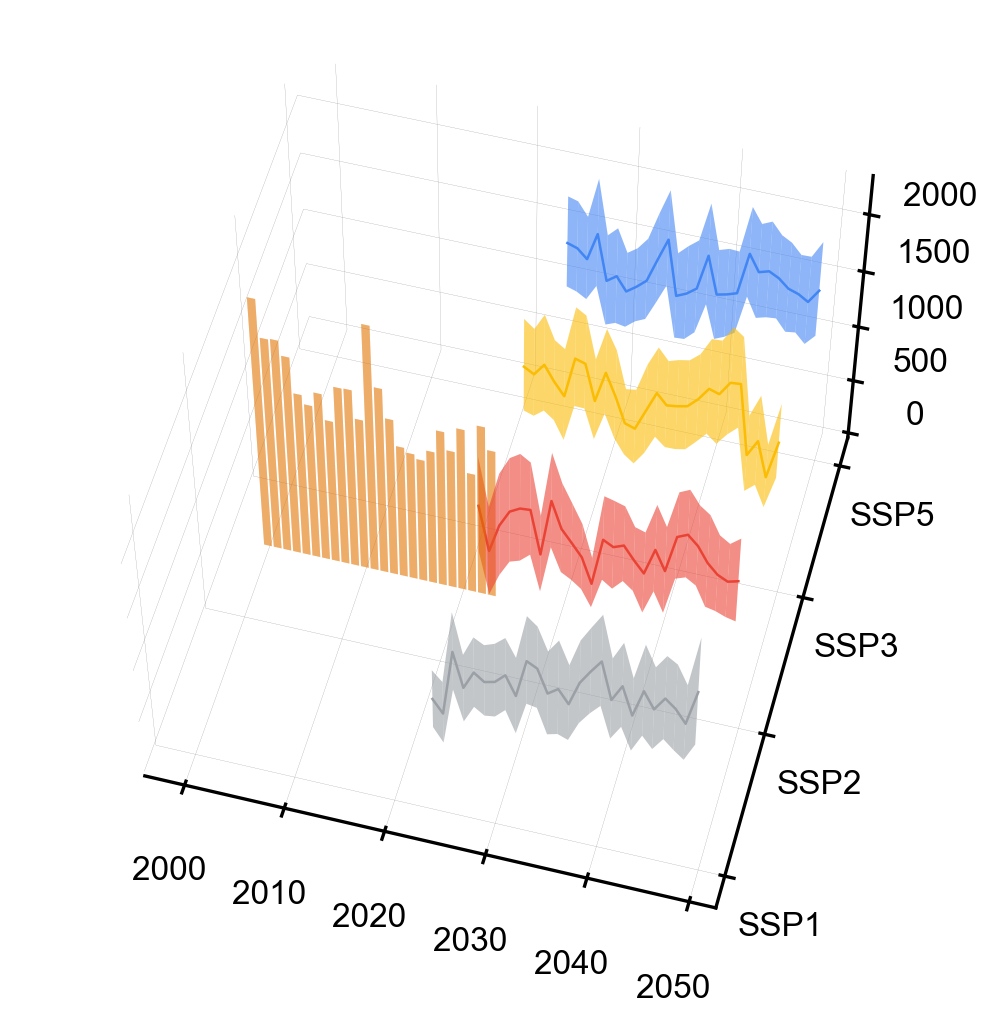

              0            1            2            3            4
0   2281.494098  1058.217964  1533.868225  1546.931278  1468.789635
1   1948.086917   939.214203  1135.607039  1498.139270  1440.806191
2   1956.799627  1551.426245  1393.681567  1603.306427  1362.223951
3   1827.802816  1233.211262  1543.571397  1469.672432  1604.018277
4   1511.498263  1401.734987  1592.858146  1358.973926  1205.296762
5   1431.980383  1334.060333  1600.971655  1717.930589  1265.941604
6   1559.409030  1357.716162  1210.171949  1691.167012  1147.297823
7   1328.155683  1443.377793  1724.457270  1375.127400  1208.569214
8   1650.120290  1268.943926  1489.348236  1650.692567  1282.675270
9   1654.364789  1621.557819  1380.972545  1457.984184  1487.943229
10  1401.047920  1574.276547  1268.532267  1232.511592  1686.211314
11  2262.834946  1360.649867  1040.482341  1203.105635  1203.250004
12  1725.924254  1425.856440  1474.275904  1385.380280  1242.684932
13  1465.613065  1304.701824  1427.430387  1567.

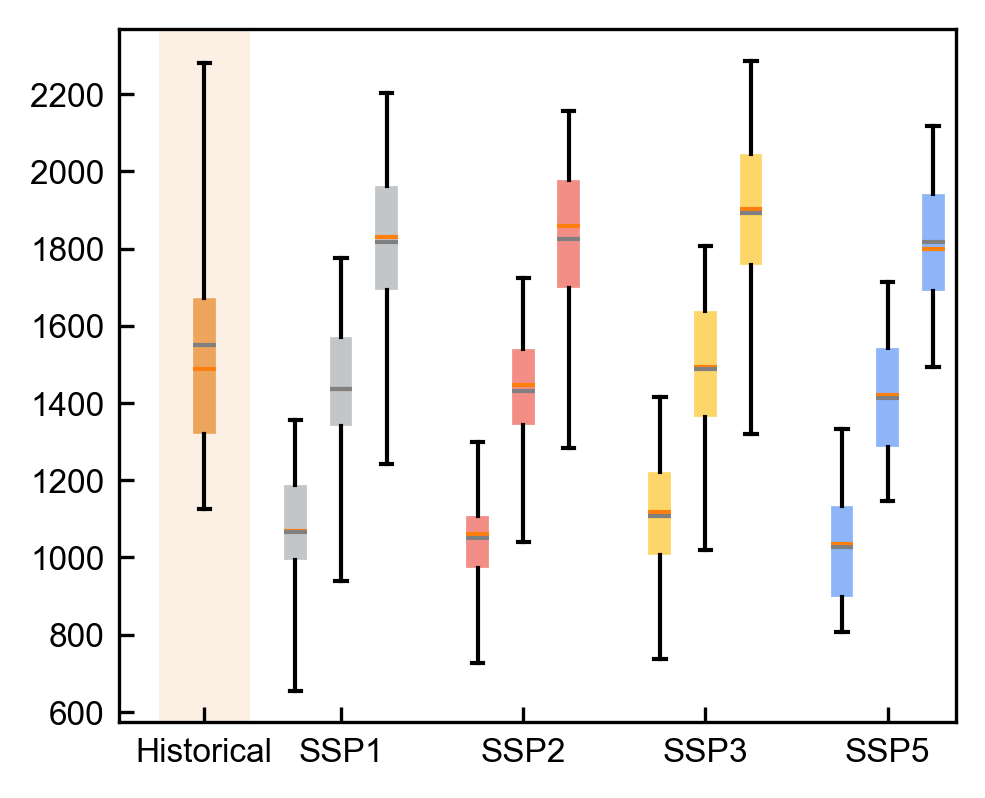

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
water_percent = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/Water_Percent.xlsx')
sampling_water_percent = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/sampling_for_production_percentage.xlsx', usecols=lambda column: column not in ['Unnamed: 0'])

from mpl_toolkits.mplot3d.art3d import Poly3DCollection

'''
# Data
previous_data = {
    "Year": [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
             2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
    "Value": [2201.239861, 1879.560670, 1887.966901, 1763.507703, 1458.329535, 1381.608790,
              1504.554985, 1281.436246, 1592.075369, 1596.170563, 1351.764412, 2183.237067,
              1665.212840, 1414.058403, 1188.301581, 1150.028463, 1112.019481, 1207.388310,
              1405.617009, 1249.544738, 1463.268468, 1086.639767, 1526.283632, 1330.403125]
}

# Create DataFrame
df_previous = pd.DataFrame(previous_data)

# Set 'Year' as the index
df_previous.set_index('Year', inplace=True)



years = np.arange(2024, 2050)  # Example years from 1995 to 2020


# Create a 2x1 subplot
fig, axs = plt.subplots(4, 1, figsize=(7.2, 5),
                        sharey=True,
                        sharex=True)

# fig, ax = plt.subplots(1, 1, figsize=(4, 3))

# Colors for different predictions
colors = ['#4285F4', '#EA4335', '#FBBC04', '#34A853']
colors = ['#9AA0A6', '#EA4335', '#FBBC04', '#4285F4']

line_styles = ['-', '--', '-.', ':']

future_average=[]
# First subplot: first two base_predictions
for i, (key, base_pred) in enumerate(list(base_predictions.items())):
    # Reshape the base predictions
    reshaped_data = base_pred.reshape(17, 26)

    # Perform the dot product
    results = np.dot(sampling_water_percent, reshaped_data)

    # Create DataFrame
    df = pd.DataFrame(results.T, index=years)

    # Calculate the statistics
    average_values = df.mean(axis=1)
    min_values = df.min(axis=1)
    max_values = df.max(axis=1)

    future_average.append(average_values)
    future_average.append(min_values)
    future_average.append(max_values)
    # Plotting
    axs[i].plot(df_previous.index, df_previous['Value'], color='#202124', linewidth=0.5)
    axs[i].plot(df.index, average_values, label=f'Average {key}', color=colors[i], linestyle='--', linewidth=0.5)
    axs[i].fill_between(df.index, min_values, max_values, color=colors[i], alpha=0.1, label=f'Min/Max Range {key}', edgecolor='none')
    axs[i].axvspan(2023, 2024, facecolor='#9AA0A6', alpha=0.3, edgecolor='none')

'''









import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Sample data as given by user
previous_data = {
    "Year": [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
             2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
    "Value": [
    2281.494098,
    1948.086917,
    1956.799627,
    1827.802816,
    1511.498263,
    1431.980383,
    1559.409030,
    1328.155683,
    1650.120290,
    1654.364789,
    1401.047920,
    2262.834946,
    1725.924254,
    1465.613065,
    1231.625454,
    1191.956950,
    1152.562212,
    1251.408059,
    1456.863909,
    1295.101454,
    1516.617263,
    1126.257188,
    1581.929875,
    1378.907828
]}

# Create DataFrame
df_previous = pd.DataFrame(previous_data)

# Set 'Year' as the index
df_previous.set_index('Year', inplace=True)


years = np.arange(2024, 2050)  # Example years from 2024 to 2050


# Colors for different predictions
colors = ['#9AA0A6', '#EA4335', '#FBBC04', '#4285F4']

# colors = ['#9AA0A6', '#FAD2CF', '#FEEFC3', '#4285F4']
# Create a 3D plot
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')

all_average_values=[]
all_min_values=[]
all_max_values=[]
all_average_values.append(np.array(df_previous['Value']))
# Iterate over the base_predictions and plot them

base_predictions ={
    'SSP1': reshaped_data1,
    'SSP2': reshaped_data2,
    'SSP3': reshaped_data3,
    'SSP5': reshaped_data4
}

for i, (key, base_pred) in enumerate(base_predictions.items()):
    # Reshape the base predictions
    reshaped_data = base_pred.reshape(17, 26)

    # Perform the dot product
    results = np.dot(sampling_water_percent, reshaped_data)

    # Create DataFrame
    df = pd.DataFrame(results.T, index=years)

    # Calculate the statistics
    average_values = df.mean(axis=1)
    min_values = df.min(axis=1)
    max_values = df.max(axis=1)
    all_average_values.append(average_values)
    all_min_values.append(min_values)
    all_max_values.append(max_values)
    # print(average_values)
    # Plotting
    ax.bar(df_previous.index, df_previous['Value'],[1.5]*len(df_previous.index), zdir='y',color='#E37400', alpha=0.2)
    ax.plot(df.index, [i]*len(df.index), average_values, label=f'Average {key}', color=colors[i], linestyle='-', linewidth=0.6)
    # ax.plot(df.index, [i]*len(df.index), min_values, color=colors[i], alpha=0.5)
    # ax.fill_between(df.index, min_values, max_values, color=colors[i], alpha=0.1, label=f'Min/Max Range {key}', edgecolor='none')
    for j in range(len(df.index)-1):
        verts = [
            [df.index[j], i, min_values.iloc[j]],
            [df.index[j], i, max_values.iloc[j]],
            [df.index[j+1], i, max_values.iloc[j+1]],
            [df.index[j+1], i, min_values.iloc[j+1]],
        ]
        poly = Poly3DCollection([verts], color=colors[i], alpha=0.6, edgecolor='none')
        ax.add_collection3d(poly)
    # ax.plot(df.index, [i]*len(df.index), max_values, color=colors[i], alpha=0.5)

# make the panes transparent
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# ax.set_xlabel('Year')
# ax.set_ylabel('Prediction Index')
# ax.set_zlabel('Value')
# ax.legend()

ax.view_init(elev=55, azim=-75)

yticks = [0, 1, 2, 3]
ax.set_yticks(yticks)
ax.set_yticklabels(['SSP1','SSP2','SSP3','SSP5'])

ax.grid(True)
ax.xaxis._axinfo['grid'].update(color = 'gray', linestyle = '-', linewidth = 0.05)
ax.yaxis._axinfo['grid'].update(color = 'gray', linestyle = '-', linewidth = 0.05)
ax.zaxis._axinfo['grid'].update(color = 'gray', linestyle = '-', linewidth = 0.05)

# ax.set_rasterized(True)
# plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/manuscript fig/fig2_3dpoly.eps',format='eps', dpi=600)
plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/figure_uncertaintyplot.tiff',dpi=300, bbox_inches='tight')
plt.show()



##############################
#box plots
import seaborn as sns
average_values_df = pd.DataFrame(all_average_values).T
# colors = ['#E37400','#9AA0A6', '#EA4335', '#FBBC04', '#4285F4']
# # Create the boxplot
# plt.figure(figsize=(10, 6))
# order = ['A', 'B', 'C', 'D', 'E']

# sns.boxplot(data=average_values_df, order=order, palette=colors, positions=[0, 2, 5, 8, 11])


# sns.boxplot(data=all_min_values, palette=colors, positions=[1, 4, 7, 10])
# sns.boxplot(data=all_max_values, palette=colors, positions=[3,6,9,12])

# plt.axvspan(-0.5, 0.5, facecolor='#9AA0A6', alpha=0.2, edgecolor='none')
# plt.title('Boxplot of Average Values for Each Model')
# plt.ylabel('Average Value')
# plt.xlabel('Model')
# plt.show()

fig, ax = plt.subplots(figsize=(3.6, 3))

print(average_values_df)
flierprops = dict(marker='o', color='k', markersize=2,markeredgewidth=0.5)
boxprops = dict(color='white', linewidth=0.1)
meanprops = {
    'linestyle': '-',  # Dashed line
    'color': 'grey',    # Blue color
    'linewidth': 1      # Line width
}

bplot1 =ax.boxplot(np.array(df_previous['Value']), patch_artist=True, positions=[-1], showmeans=True, meanline=True,  widths=0.5, whis=3,  flierprops=flierprops, boxprops=boxprops, meanprops=meanprops)
bplot2 =ax.boxplot(average_values_df, positions=[0, 2, 6, 10, 14], patch_artist=True ,showmeans=True, meanline=True,  widths=0.5, whis=3,flierprops=flierprops, boxprops=boxprops, meanprops=meanprops)  # will be used to label x-ticks

bplot3 =ax.boxplot(all_min_values, positions=[1, 5, 9, 13],patch_artist=True, showmeans=True, meanline=True, widths=0.5, whis=3,flierprops=flierprops, boxprops=boxprops, meanprops=meanprops)
bplot4 =ax.boxplot(all_max_values, positions=[3,7,11,15], patch_artist=True, showmeans=True, meanline=True, widths=0.5, whis=3,flierprops=flierprops, boxprops=boxprops, meanprops=meanprops)
ax.axvspan(-2, 0, facecolor='#E37400', alpha=0.1, edgecolor='none')


colors = ['#E37400','#9AA0A6', '#EA4335', '#FBBC04', '#4285F4']
# fill with colors
for patch in bplot1['boxes']:
    patch.set_facecolor(colors[0])
    patch.set_alpha(0.6)

# For average_values_df boxplot
for patch, color in zip(bplot2['boxes'], colors[:len(bplot2['boxes'])]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# For all_min_values boxplot
for patch, color in zip(bplot3['boxes'], colors[1:(len(bplot3['boxes'])+1)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# For all_max_values boxplot
for patch, color in zip(bplot4['boxes'], colors[1:(len(bplot4['boxes'])+1)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

xticks = [-1, 2, 6, 10, 14]
ax.set_xticks(xticks)
ax.set_xticklabels(['Historical','SSP1','SSP2','SSP3','SSP5'])
ax.set_rasterized(True)
# plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/manuscript fig/fig2_box.eps',format='eps', dpi=600)
plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/figure_boxplot.tiff',dpi=300, bbox_inches='tight')
plt.show()




# Display the plot

# axs[1].set_ylabel('Water consumption (m$^3$/1000kg)')
# axs[3].set_xlabel('Year')

# plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/fig_future_range.tiff',dpi=300, bbox_inches='tight')
# plt.show()


average_values_df.to_excel('/content/drive/MyDrive/NU work/Cotton/Water_future_average.xlsx')

In [24]:
print(average_values_df)

              0            1            2            3            4
0   2281.494098  1058.217964  1533.868225  1546.931278  1468.789635
1   1948.086917   939.214203  1135.607039  1498.139270  1440.806191
2   1956.799627  1551.426245  1393.681567  1603.306427  1362.223951
3   1827.802816  1233.211262  1543.571397  1469.672432  1604.018277
4   1511.498263  1401.734987  1592.858146  1358.973926  1205.296762
5   1431.980383  1334.060333  1600.971655  1717.930589  1265.941604
6   1559.409030  1357.716162  1210.171949  1691.167012  1147.297823
7   1328.155683  1443.377793  1724.457270  1375.127400  1208.569214
8   1650.120290  1268.943926  1489.348236  1650.692567  1282.675270
9   1654.364789  1621.557819  1380.972545  1457.984184  1487.943229
10  1401.047920  1574.276547  1268.532267  1232.511592  1686.211314
11  2262.834946  1360.649867  1040.482341  1203.105635  1203.250004
12  1725.924254  1425.856440  1474.275904  1385.380280  1242.684932
13  1465.613065  1304.701824  1427.430387  1567.

In [25]:
import numpy as np

'''
data_production_percent = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/Production_Percent.xlsx', usecols=range(1,18))

print(data_production_percent)
# Example arrays of min and max values
min_values = data_production_percent.min()
print(min_values)
# np.array([0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.20, 0.21])
max_values = data_production_percent.max()
# np.array([0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26])

# Define data_ranges by zipping the min and max arrays
data_ranges = list(zip(min_values, max_values))


# Number of samples
n_samples = 1000

# Initialize an array to hold the normalized samples
valid_samples = []

# Rejection sampling function
def sample_within_ranges(data_ranges):
    while True:
        samples = np.array([np.random.uniform(low, high) for low, high in data_ranges])
        if np.isclose(samples.sum(), 1, atol=1e-4):  # Check if the sum is close to 1
            return samples

# Generate valid samples
for _ in range(n_samples):
    valid_samples.append(sample_within_ranges(data_ranges))

# Convert the list of valid samples to a NumPy array
valid_samples_array = np.array(valid_samples)
print(valid_samples_array)
'''
# pd.DataFrame(valid_samples_array).to_excel('/content/drive/MyDrive/NU work/Cotton/sampling_for_production_percentage.xlsx')

"\ndata_production_percent = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/Production_Percent.xlsx', usecols=range(1,18))\n\nprint(data_production_percent)\n# Example arrays of min and max values\nmin_values = data_production_percent.min()\nprint(min_values)\n# np.array([0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.20, 0.21])\nmax_values = data_production_percent.max()\n# np.array([0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26])\n\n# Define data_ranges by zipping the min and max arrays\ndata_ranges = list(zip(min_values, max_values))\n\n\n# Number of samples\nn_samples = 1000\n\n# Initialize an array to hold the normalized samples\nvalid_samples = []\n\n# Rejection sampling function\ndef sample_within_ranges(data_ranges):\n    while True:\n        samples = np.array([np.random.uniform(low, high) for low, high in data_ranges])\n        if np.isclose(samples.sum(), 1, atol=1e-4):  #